(lecture12:homework)=
# Homework 12

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name: Pranay**
+ **Last Name: Gohel**
+ **Email: gohelp@purdue.edu**

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_597/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


(lecture12:homework:problem2)=
## Problem 1 - Comparing performance of robotic systems

You are considering purchasing a robotic system for manufacturing masks.
There are two possibilities, say $A$ and $B$.
They both produce the same number of masks per day, they cost the same to purchase, and the have the same power and supply costs.
However, they are not identical. They have different faulty mask rates.
Let $X_A$ and $X_B$ be the number of faulty masks you get from each system, respectively, in a given day.
For each of the possibilities below:

1) Use `scipy.stats` to make two Normal random variables $X_A$ and $X_B$ with the right mean and variance.

2) Plot the PDF of the random variables in the same figure.

3) Find a 95% central credible interval.

3) Indicate which robotic system you would buy and why (three choices $A$, $B$, and ``I cannot choose'').


+ **Case 1:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.1$ and $\mathbf{E}[X_B] = 1, \mathbf{V}[X_B] = 0.2$.

**Answer:**

In [2]:
# Make the random variables here
XA = st.norm(loc=1, scale=np.sqrt(0.1))
XB = st.norm(loc=1, scale=np.sqrt(0.2))

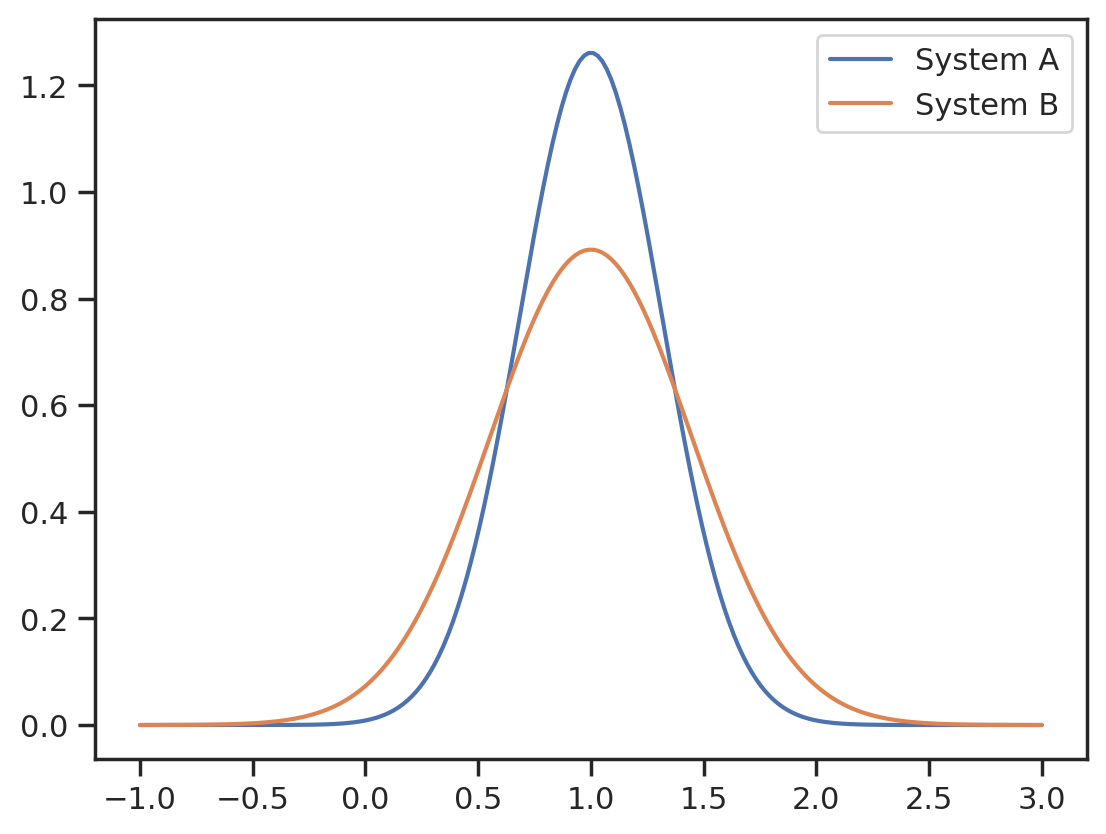

In [3]:
# Plot the PDF's here
xs = np.linspace(-1, 3, 200)
plt.plot(xs, XA.pdf(xs), label='System A')
plt.plot(xs, XB.pdf(xs), label='System B')
plt.legend()
plt.show()

In [4]:
# Find the 95% central credible interval for XA here
print(f"XA Interval: {XA.ppf(0.025):.2f} to {XA.ppf(0.975):.2f}")

XA Interval: 0.38 to 1.62


In [5]:
# Find the 95% central credible interval for XB here
print(f"XB Interval: {XB.ppf(0.025):.2f} to {XB.ppf(0.975):.2f}")

XB Interval: 0.12 to 1.88


*Both have the same expected number of faulty masks (1), but System A is the better choice due to its smaller/narrow 95% central credible interval, meaning we can be more confident in choosing System A. It also has half the variance.*

+ **Case 2:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.1$ and $\mathbf{E}[X_B] = 2, \mathbf{V}[X_B] = 0.1$.

**Answer:**

In [7]:
# Make the random variables here
XA = st.norm(loc=1, scale=np.sqrt(0.1))
XB = st.norm(loc=2, scale=np.sqrt(0.1))

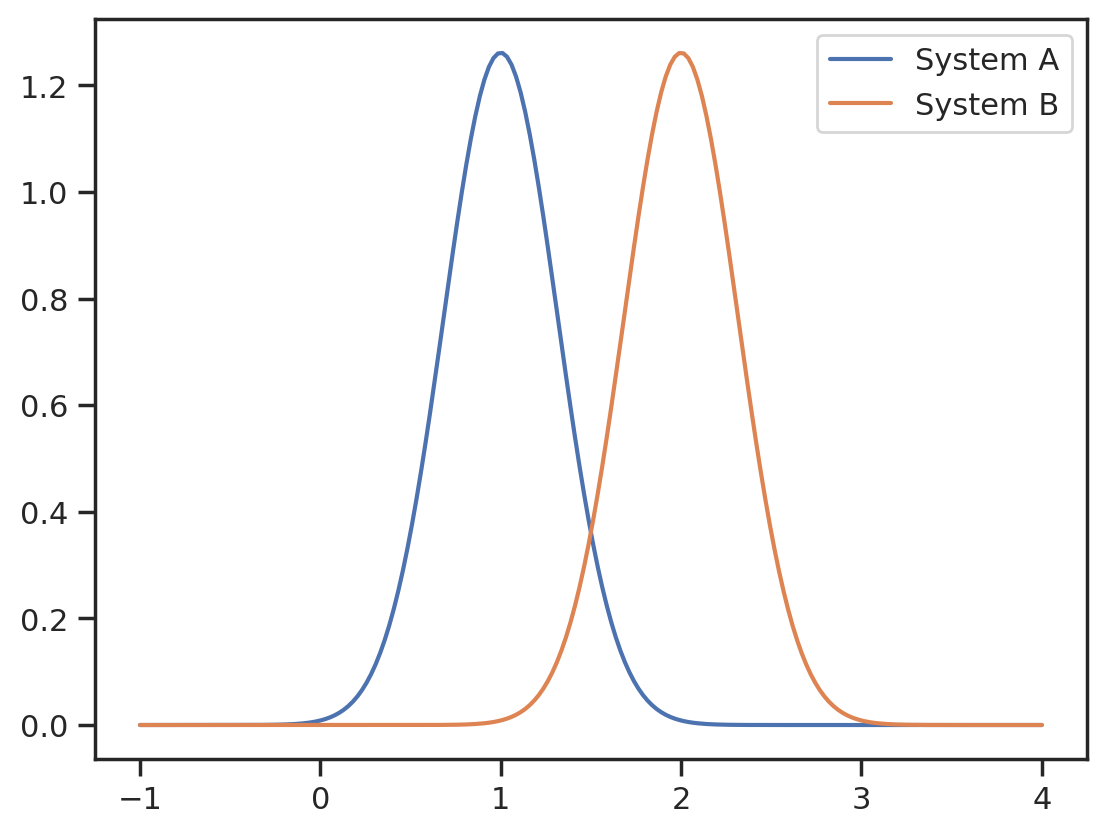

In [8]:
# Plot the PDF's here
xs = np.linspace(-1, 4, 200)
plt.plot(xs, XA.pdf(xs), label='System A')
plt.plot(xs, XB.pdf(xs), label='System B')
plt.legend()
plt.show()

In [9]:
# Find the 95% central credible interval for XA here
print(f"XA Interval: {XA.ppf(0.025):.2f} to {XA.ppf(0.975):.2f}")

XA Interval: 0.38 to 1.62


In [10]:
# Find the 95% central credible interval for XB here
print(f"XB Interval: {XB.ppf(0.025):.2f} to {XB.ppf(0.975):.2f}")

XB Interval: 1.38 to 2.62


*Here, both Systems A and B share the rame 95% central credible interval range (1.24), but since System A has half the number of expected faulty masks (1 vs 2), it is the better choice.*

+ **Case 3:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.3$ and $\mathbf{E}[X_B] = 1.1, \mathbf{V}[X_B] = 0.1$.

**Answer:**

In [11]:
# Make the random variables here
XA = st.norm(loc=1, scale=np.sqrt(0.3))
XB = st.norm(loc=1.1, scale=np.sqrt(0.1))

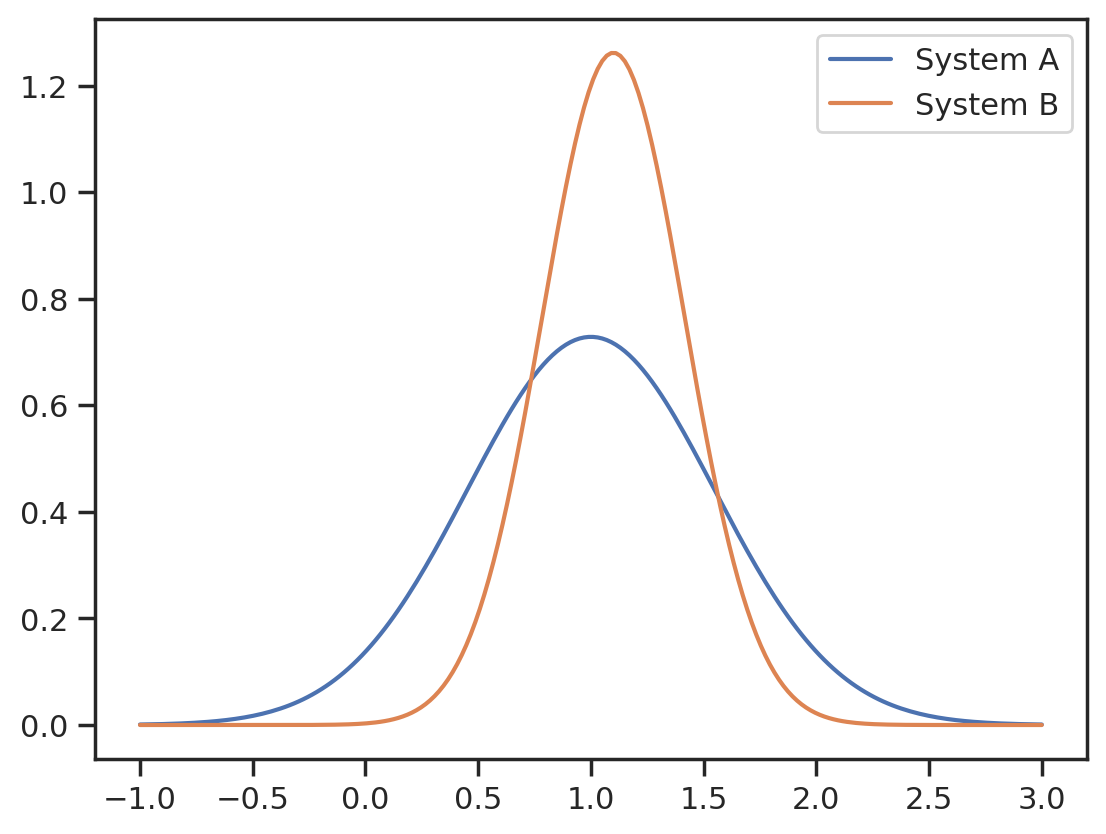

In [12]:
# Plot the PDF's here
xs = np.linspace(-1, 3, 200)
plt.plot(xs, XA.pdf(xs), label='System A')
plt.plot(xs, XB.pdf(xs), label='System B')
plt.legend()
plt.show()

In [13]:
# Find the 95% central credible interval for XA here
print(f"XA Interval: {XA.ppf(0.025):.2f} to {XA.ppf(0.975):.2f}")

XA Interval: -0.07 to 2.07


In [14]:
# Find the 95% central credible interval for XA here
print(f"XB Interval: {XB.ppf(0.025):.2f} to {XB.ppf(0.975):.2f}")

XB Interval: 0.48 to 1.72


*I would buy System B due to the much lower variance, even though the mean is slightly higher, the benefit outweighs the risk/chance of having a very high fault count.*

## Problem 2 - Figuring out which household conserves less energy

In this homework problem, we are going to look at a dataset for which the Normal is not a good fit.
In particular, we are going to look at HVAC energy consumption in our high-performance building data.

In [15]:
import requests
import os

# The url of the file we want to download
url = 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-297-intro-to-data-science/master/data/temperature_raw.xlsx'
!curl -O $url

import numpy as np
import pandas as pd
df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0   892k      0 --:--:-- --:--:-- --:--:--  890k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536
...,...,...,...,...,...,...
5643,c44,2020-02-25,59.0,43.642388,76.494637,19.135139
5644,c45,2020-02-25,87.0,43.642388,71.165052,30.794281
5646,c47,2020-02-25,97.0,43.642388,68.603287,5.339391
5647,c48,2020-02-25,92.0,43.642388,73.429239,18.040078


+ Extract the `hvac` column for household `a5`:

In [16]:
hvac_a5 = df[df['household'] == 'a5']['hvac']

+ Do the histogram of `hvac` for household `a5`:

Text(0, 0.5, 'Density')

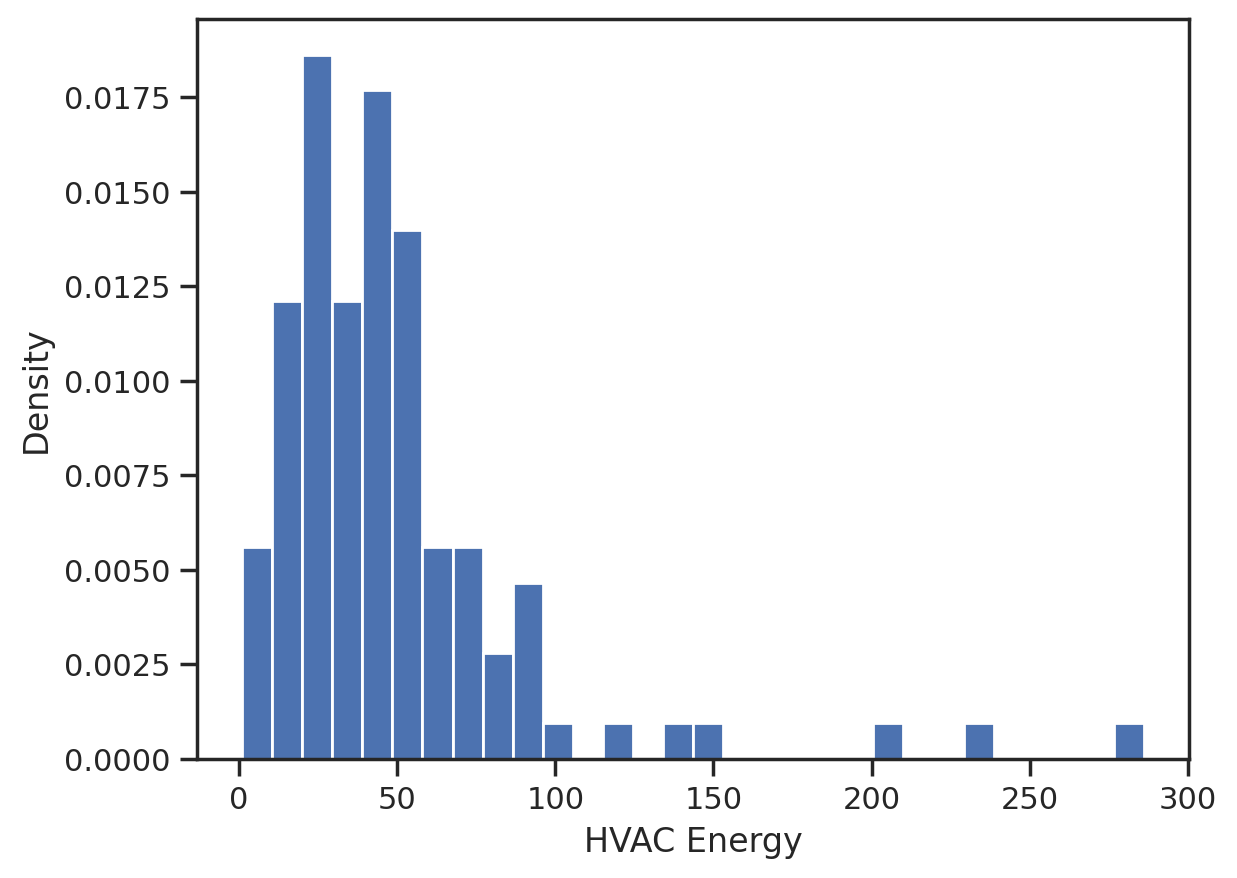

In [17]:
plt.hist(hvac_a5, bins=30, density=True)
plt.xlabel('HVAC Energy')
plt.ylabel('Density')

+ Use the method of moments to fit a Normal distribution to the `hvac` data for household `a5`:

In [19]:
mu_a5 = hvac_a5.mean()
sigma2_a5 = np.mean(hvac_a5**2) - mu_a5**2
HVAC_a5 = st.norm(loc=mu_a5, scale=np.sqrt(sigma2_a5))

+ In the same figure, show the histogram of `hvac` data for household `a5` (use `density=True` to make sure itis normalized) and the PDF of the Normal you just fitted.
Is this a good fit? Why do you think we do not get a good fit?

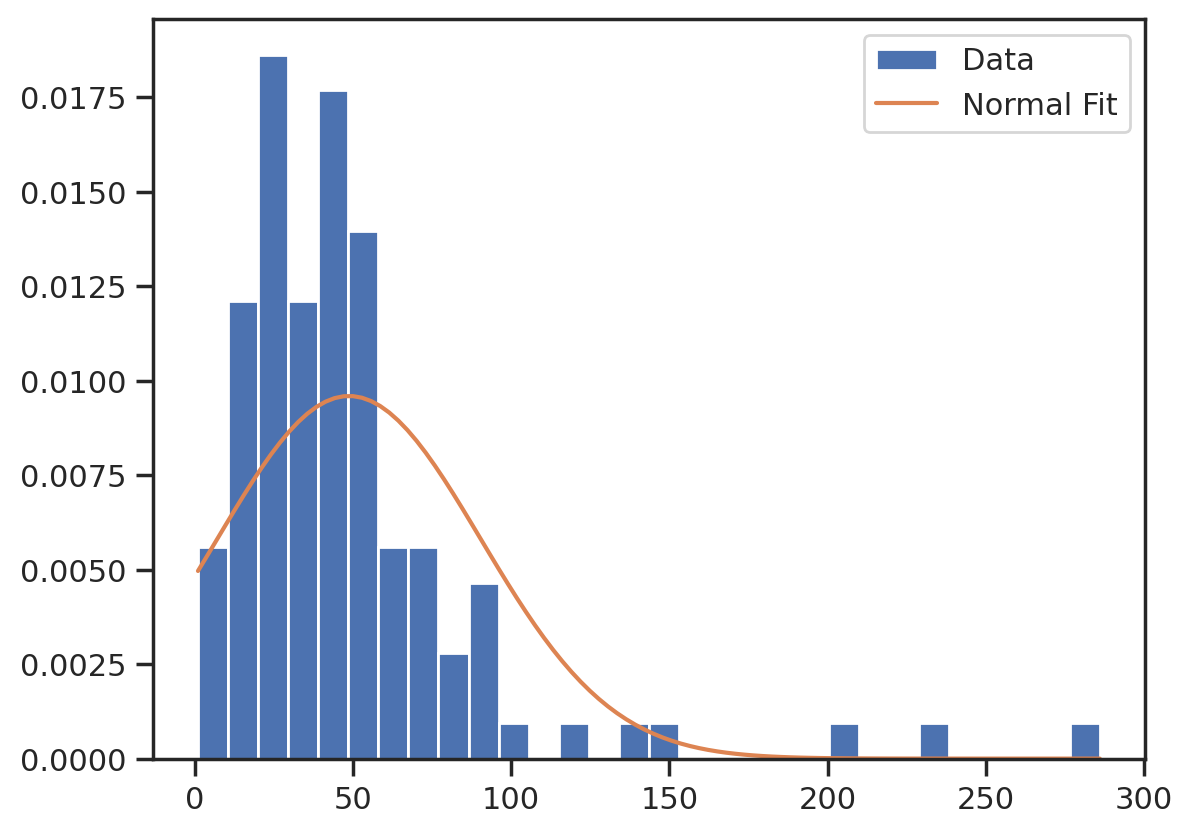

In [20]:
xs = np.linspace(hvac_a5.min(), hvac_a5.max(), 100)
plt.hist(hvac_a5, bins=30, density=True, label='Data')
plt.plot(xs, HVAC_a5.pdf(xs), label='Normal Fit')
plt.legend()

*I believe we don't get a good fit because the data is positive and very skewed (ex between 0 and 50), whereas a normal ("bell curve") is symmetric and not skewed to the left or right, like this data is.*

+ Now I am asking you to transform the data in a way that will make them look more Normal.
Do the histogram of the logarithm of the `hvac` data for household `a5`:

In [22]:
log_hvac_a5 = np.log(hvac_a5)

+ Fit a Normal to the logarithm of the `hvac` data for household `a5`:

In [23]:
mu_log_a5 = log_hvac_a5.mean()
sigma_log_a5 = log_hvac_a5.std()
Log_HVAC_a5 = st.norm(loc=mu_log_a5, scale=sigma_log_a5)

+ In the same figure, show the histogram of the **logarithm** of the `hvac` data for household `a5` and the PDF of the Normal you just fitted. Does this look like a good fit?

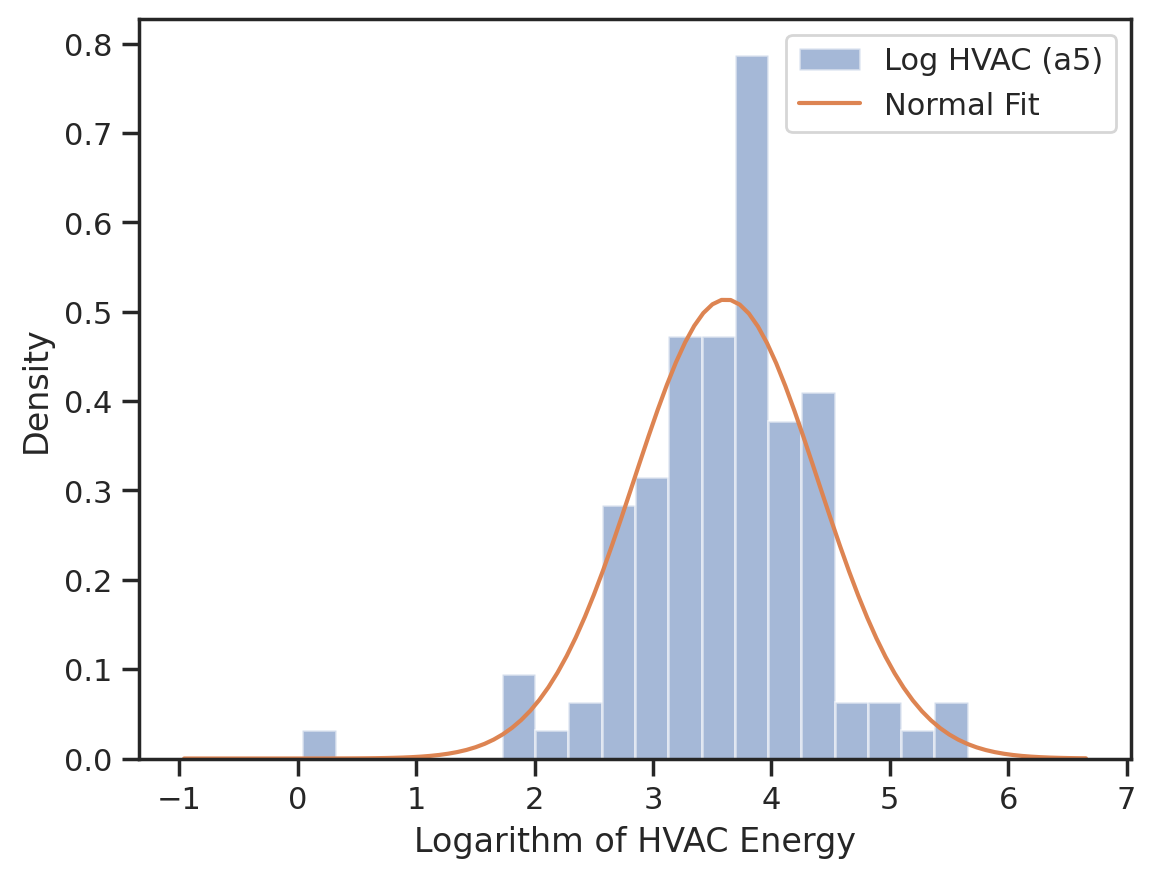

In [24]:
xs = np.linspace(log_hvac_a5.min() - 1, log_hvac_a5.max() + 1, 100)
plt.hist(log_hvac_a5, bins=20, density=True, alpha=0.5, label='Log HVAC (a5)')
plt.plot(xs, Log_HVAC_a5.pdf(xs), label='Normal Fit')
plt.xlabel('Logarithm of HVAC Energy')
plt.ylabel('Density')
plt.legend()
plt.show()

*Yes, this does look like a much better fit. When the data is represented using log, it fits the normal/"bell curve" distribution much better.*

+ Now do exactly the same thing as the previous bullet point for household `a3`.

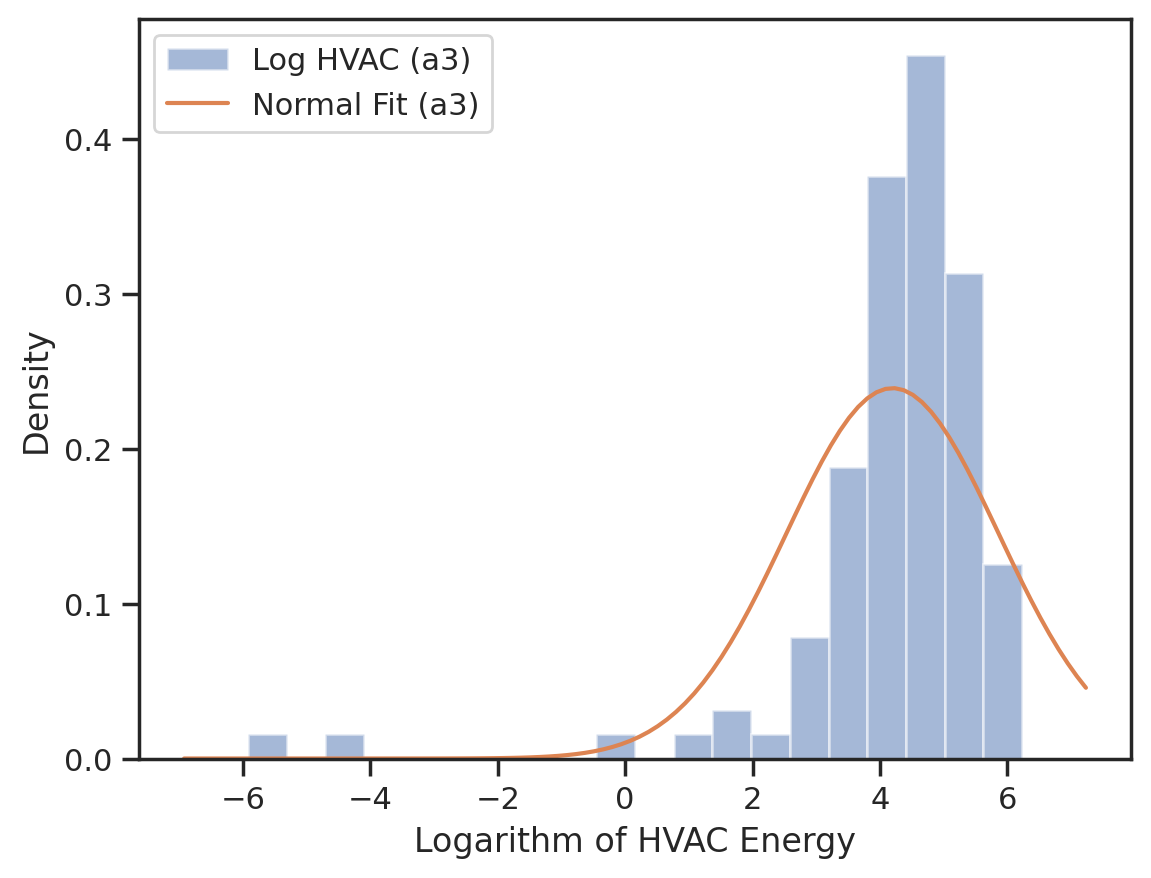

In [25]:
hvac_a3 = df[df['household'] == 'a3']['hvac']

log_hvac_a3 = np.log(hvac_a3)
mu_log_a3 = log_hvac_a3.mean()
sigma_log_a3 = log_hvac_a3.std()
Log_HVAC_a3 = st.norm(loc=mu_log_a3, scale=sigma_log_a3)

xs_a3 = np.linspace(log_hvac_a3.min() - 1, log_hvac_a3.max() + 1, 100)
plt.hist(log_hvac_a3, bins=20, density=True, alpha=0.5, label='Log HVAC (a3)')
plt.plot(xs_a3, Log_HVAC_a3.pdf(xs_a3), label='Normal Fit (a3)')
plt.xlabel('Logarithm of HVAC Energy')
plt.ylabel('Density')
plt.legend()
plt.show()

+ Which household consumes more energy, `a5` or `a3`?

In [26]:
mean_a5 = hvac_a5.mean()
mean_a3 = hvac_a3.mean()

print(f"Average HVAC consumption for a5: {mean_a5:.2f}")
print(f"Average HVAC consumption for a3: {mean_a3:.2f}")

Average HVAC consumption for a5: 48.75
Average HVAC consumption for a3: 116.95


*As shown by the mean calculation above, the a3 household consumes more energy since it is over 2 times greater.*

## Problem 3 - Introducing the Log-Normal distribution

In the previous problem, we took the logarithm of `hvac` in order to obtain a better fit to the Normal.
It turns out that this is a very common practice whenever you have a positive dataset that is skewed in the way we noticed above.
As a matter of fact, there is a distribution called the [Log-Normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution) which is designed to do exactly that.
Below, I show you could have fitted a Log-Normal distribution directly on the `hvac` data.

In [27]:
params = st.lognorm.fit(hvac_a5) # This does something similar to the method of moments
HVAC_a5_ln = st.lognorm(*params) # This is the random varibale
# Here is how you can sample from it:
HVAC_a5_ln.rvs(size=10)

array([78.91223106, 51.17500203, 38.59947554, 32.0953191 , 16.96589962,
       53.9014742 , 25.42017185, 50.11443694, 41.40167578,  8.42669844])

In [28]:
# Here is how you can evaluate its PDF:
HVAC_a5_ln.pdf(200)

np.float64(0.00014185114943067792)

+ In the same figure, plot the PDF of the Log-normal along with the histogram of the `hvac` data for `a5`.

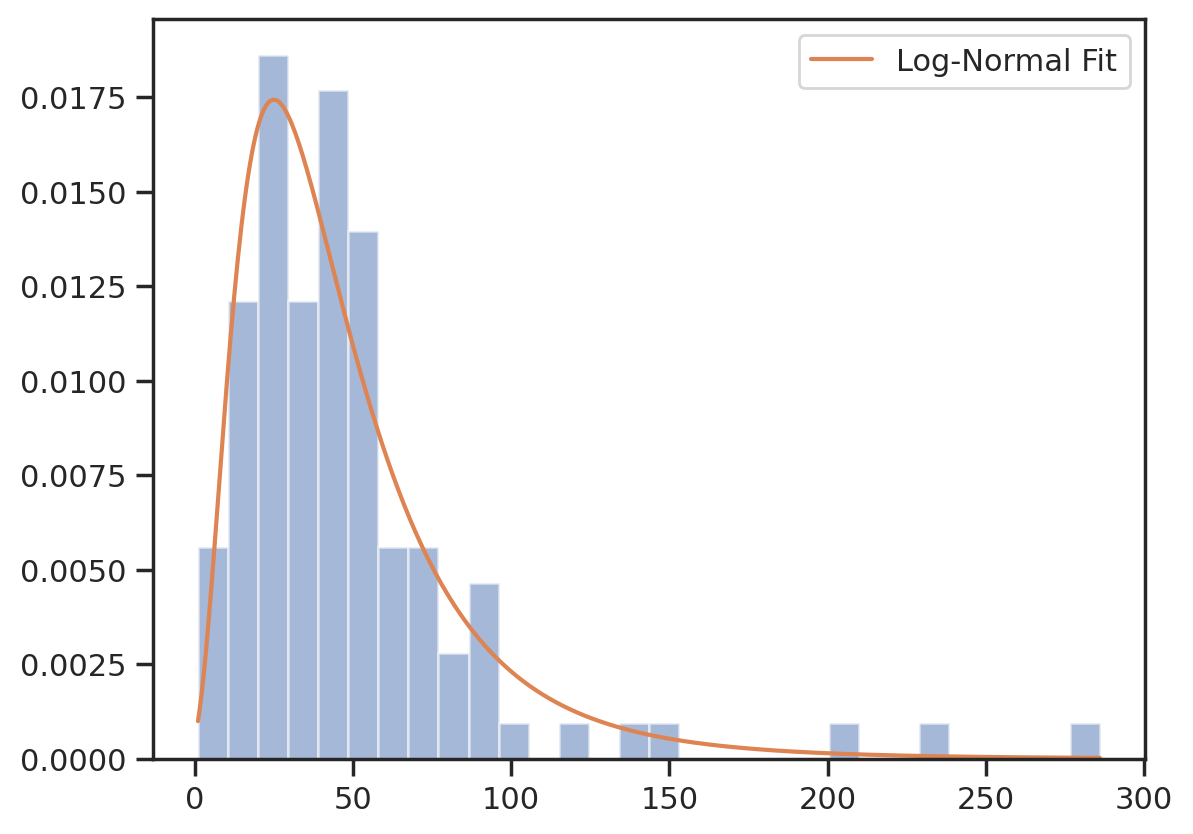

In [29]:
xs = np.linspace(hvac_a5.min(), hvac_a5.max(), 500)
plt.hist(hvac_a5, bins=30, density=True, alpha=0.5)
plt.plot(xs, HVAC_a5_ln.pdf(xs), label='Log-Normal Fit')
plt.legend()

+ Is the fit with Log-Normal good?

*Yes, the fit with Log-Normal is good, as most of the data and its peak falls under the curve, despite it being skewed.*

+ Recall how in [](lecture12:standard-normal-quantiles) we used the `ppf()` function of a random variable to find quantiles.
Use this function to find the 0.025-quantile of the Log-Normal we constructed above.

In [30]:
q025 = HVAC_a5_ln.ppf(0.025)

+ Now find the 95% central credible interval of the Log-Normal variable we constructed above.

In [34]:
q975 = HVAC_a5_ln.ppf(0.975)

+ Repeat as many code-blocks as you need to fit a Log-Normal to the `hvac` data for household `a3` and then find the 95% central credible interval of the resulting random variable.

In [35]:
params_a3 = st.lognorm.fit(hvac_a3)
HVAC_a3_ln = st.lognorm(*params_a3)

q025_a3 = HVAC_a3_ln.ppf(0.025)
q975_a3 = HVAC_a3_ln.ppf(0.975)
print(f"The 95% central credible interval for a3 is: [{q025_a3:.2f}, {q975_a3:.2f}]")

The 95% central credible interval for a3 is: [4.24, 418.67]


+ By comparing the 95% central credible intervals constructed above, which household `a5` or `a3` consumes more energy?

*As noticed and shown by the code block below, household a3 consumes more energy. This is because the interval goes up to 418.67, so with 95% probability the energy usage will be much higher.*

In [37]:
print(f"Household a5 95% Interval: [{q025:.2f}, {q975:.2f}]")
print(f"Household a3 95% Interval: [{q025_a3:.2f}, {q975_a3:.2f}]")

Household a5 95% Interval: [7.49, 142.80]
Household a3 95% Interval: [4.24, 418.67]


Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_12.ipynb'